<a href="https://colab.research.google.com/github/devdatta1429/BDA_Assignments/blob/main/PML/Day_18_05_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

import os
os.chdir('/content/drive/MyDrive/CDAC/')

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

from numpy import random
from collections import Counter

from numpy.linalg import inv
from numpy.linalg import eig

import matplotlib
from matplotlib import pyplot as plt

import seaborn as sns

import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel

import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split

import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from scipy.stats import chisquare
from scipy.stats import chi2_contingency

from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson
from statsmodels.stats.rates import test_poisson_2indep

from scipy.stats import chi2

from scipy.stats import f
from sklearn.metrics import mean_squared_error


#========================================================================

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp

import sklearn
from sklearn.model_selection import train_test_split



import pandas as pd
import sklearn
from sklearn import linear_model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_excel('StudentData.xlsx' )
df.head()

,Unnamed: 0,StudyHours,PracticeTests,RevisionHours,CoachingHours,Attendance,MobileUsage,NetflixHours,GamingHours,SocialMedia,SportsHours,Marks
0,0,7.0,2.9,7.1,2.6,77.0,6.9,5.5,2.2,7.9,2.4,184.7
1,1,5.7,4.4,5.9,4.2,82.0,8.8,2.2,4.6,5.0,1.6,185.5
2,2,7.3,4.5,7.6,4.7,85.0,2.2,5.7,1.9,6.2,2.0,189.9
3,3,9.0,3.8,9.4,4.0,85.2,6.1,6.7,0.9,5.1,3.3,190.5
4,4,5.5,4.8,5.1,4.8,82.7,3.7,4.8,0.7,5.1,2.2,185.0


#### 🔰Ridge & lasso regression🔰

In [3]:
df = df.drop('Unnamed: 0', axis=1)

# Split for train-test
x_train, x_test, y_train, y_test = train_test_split(df.drop('Marks', axis=1),df.Marks, test_size=0.2, random_state=20)

In [4]:

# Add constant term
x_train = sm.add_constant(x_train, prepend=False)
x_test = sm.add_constant(x_test, prepend=False)



In [5]:
# Prepare the model
mod1 = sm.OLS(y_train,x_train).fit()

print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Marks   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     17.96
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           1.38e-15
Time:                        18:01:27   Log-Likelihood:                -266.22
No. Observations:                  80   AIC:                             554.4
Df Residuals:                      69   BIC:                             580.6
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
StudyHours        4.9723      2.752      1.807

In [6]:
df.corr()

,StudyHours,PracticeTests,RevisionHours,CoachingHours,Attendance,MobileUsage,NetflixHours,GamingHours,SocialMedia,SportsHours,Marks
StudyHours,1.000000,-0.137275,0.985756,-0.166741,-0.139500,-0.148479,0.039702,-0.119595,-0.116330,0.054158,0.461595
PracticeTests,-0.137275,1.000000,-0.136466,0.982391,0.187605,-0.129208,0.083350,0.098441,0.137525,0.060396,0.455356
RevisionHours,0.985756,-0.136466,1.000000,-0.164784,-0.149062,-0.170147,0.023863,-0.119828,-0.152964,0.079607,0.448704
CoachingHours,-0.166741,0.982391,-0.164784,1.000000,0.230122,-0.115819,0.088085,0.076729,0.100994,0.056112,0.444800
Attendance,-0.139500,0.187605,-0.149062,0.230122,1.000000,-0.090584,0.113714,-0.018171,0.115444,-0.152492,0.430057
MobileUsage,-0.148479,-0.129208,-0.170147,-0.115819,-0.090584,1.000000,-0.086980,0.093279,-0.107880,-0.072796,-0.104220
NetflixHours,0.039702,0.083350,0.023863,0.088085,0.113714,-0.086980,1.000000,-0.106991,0.125457,0.082534,0.140267
GamingHours,-0.119595,0.098441,-0.119828,0.076729,-0.018171,0.093279,-0.106991,1.000000,-0.065969,0.217792,-0.040819
SocialMedia,-0.116330,0.137525,-0.152964,0.100994,0.115444,-0.107880,0.125457,-0.065969,1.000000,-0.212731,0.066168
SportsHours,0.054158,0.060396,0.079607,0.056112,-0.152492,-0.072796,0.082534,0.217792,-0.212731,1.000000,-0.086149


In [7]:
x = df.drop(['Marks', 'CoachingHours', 'StudyHours'], axis =1)

we notice that the same the factor which had high corelation cooefficnt between them are also having high VIF value.

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

x = df.drop('Marks', axis=1)

vif_df = pd.DataFrame()
vif_df['Variable'] = x.columns
vif_df['VIF'] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]

print("\nVIF VALUES")
print(vif_df.sort_values('VIF', ascending=False))


VIF VALUES
        Variable         VIF
3  CoachingHours  448.533988
1  PracticeTests  444.040942
0     StudyHours  436.685659
2  RevisionHours  407.771297
4     Attendance   60.859442
8    SocialMedia   15.561370
5    MobileUsage    7.811828
9    SportsHours    5.976866
7    GamingHours    5.890728
6   NetflixHours    4.989462


In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

x = df.drop(['Marks', 'CoachingHours', 'StudyHours'], axis =1)

vif_df = pd.DataFrame()
vif_df['Variable'] = x.columns
vif_df['VIF'] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]

print("\nVIF VALUES")
print(vif_df.sort_values('VIF', ascending=False))



VIF VALUES
        Variable        VIF
2     Attendance  54.670801
0  PracticeTests  14.844545
6    SocialMedia  13.981452
1  RevisionHours  10.080112
3    MobileUsage   7.657400
7    SportsHours   5.898704
5    GamingHours   5.745141
4   NetflixHours   4.937682


In [10]:
x = df.drop('Marks', axis=1)
y=df.Marks

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

regr1 = LinearRegression()
regr1.fit(x_scaled,y)
regr1.coef_
'''
regr1.coef_
Out[37]:
array([ 5.50805023,  7.25112668,  2.0336992 , -1.39211411,  5.28411473,
        1.09301416,  0.58200739,  0.0777879 ,  0.1418704 , -1.05017386])
'''

'\nregr1.coef_\nOut[37]:\narray([ 5.50805023,  7.25112668,  2.0336992 , -1.39211411,  5.28411473,\n        1.09301416,  0.58200739,  0.0777879 ,  0.1418704 , -1.05017386])\n'

In [11]:
regr1.intercept_
regr1.feature_names_in_
'''
array(['StudyHours', 'PracticeTests', 'RevisionHours', 'CoachingHours',
       'Attendance', 'MobileUsage', 'NetflixHours', 'GamingHours',
       'SocialMedia', 'SportsHours'], dtype=object)
'''

"\narray(['StudyHours', 'PracticeTests', 'RevisionHours', 'CoachingHours',\n       'Attendance', 'MobileUsage', 'NetflixHours', 'GamingHours',\n       'SocialMedia', 'SportsHours'], dtype=object)\n"

In [12]:
ridge = Ridge(alpha=10)
ridge.fit(x_scaled,y)
ridge.coef_
'''
array([ 3.82980281,  3.32971683,  3.3198266 ,  2.26051693,  4.63360394,
        0.85365738,  0.59599171,  0.14077832,  0.33850811, -1.0176817 ])
'''

'\narray([ 3.82980281,  3.32971683,  3.3198266 ,  2.26051693,  4.63360394,\n        0.85365738,  0.59599171,  0.14077832,  0.33850811, -1.0176817 ])\n'

In [13]:
ridge.intercept_
regr1.feature_names_in_

array(['StudyHours', 'PracticeTests', 'RevisionHours', 'CoachingHours',
       'Attendance', 'MobileUsage', 'NetflixHours', 'GamingHours',
       'SocialMedia', 'SportsHours'], dtype=object)

In [14]:
lasso = Lasso(alpha=1)
lasso.fit(x_scaled,y)
lasso.coef_
'''
array([ 6.04772327,  4.72885822,  0.        ,  0.        ,  4.34663537,
        0.        ,  0.        , -0.        ,  0.        , -0.03101151])
'''

'\narray([ 6.04772327,  4.72885822,  0.        ,  0.        ,  4.34663537,\n        0.        ,  0.        , -0.        ,  0.        , -0.03101151])\n'

In [15]:
lasso.intercept_

np.float64(185.09500000000003)

In [16]:
# To get the optimum value of alpha for Lasso regression

from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(x_scaled,y)
lassocv.alpha_

np.float64(0.46968573975480105)

# 🔰Logistic Regression🔰
- Binaray - 2 Posible responses
- Nominal - >2 Posible levels
- ordinal - levels have a logical order

In [17]:
df = pd.read_excel('CDAC_DataBook.xlsx' , sheet_name = 'diabetes')

In [18]:
df.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,DietType
0,148,72,35,0,33.6,0.63,50,1,1
1,85,66,29,0,26.6,0.35,31,0,2
2,183,64,0,0,23.3,0.67,32,1,1
3,89,66,23,94,28.1,0.17,21,0,1
4,137,40,35,168,43.1,2.29,33,1,1


In [19]:
df = df[['Glucose', 'BloodPressure', 'Age', 'Outcome',	'DietType']]
df.head(2)

,Glucose,BloodPressure,Age,Outcome,DietType
0,148,72,50,1,1
1,85,66,31,0,2


In [20]:
x = df.drop('Outcome', axis = 1)
x.head(2)

,Glucose,BloodPressure,Age,DietType
0,148,72,50,1
1,85,66,31,2


In [21]:
y = df.Outcome
y.head(2)

,Outcome
0,1
1,0


In [22]:
df.head(2)

,Glucose,BloodPressure,Age,Outcome,DietType
0,148,72,50,1,1
1,85,66,31,0,2


In [23]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'diabetes')

df =df[['Glucose','BloodPressure','Age','DietType','Outcome']]

x = df.drop('Outcome', axis=1)
y = df.Outcome

diet_dummy = pd.get_dummies(x.DietType, drop_first=True, prefix='Diet').astype(int)
x = x.drop('DietType', axis=1)
x = pd.concat([x, diet_dummy], axis=1)

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=20)

x_train = sm.add_constant(x_train, prepend=False)
mod3 = sm.Logit(y_train, x_train).fit()
print(mod3.summary())

Optimization terminated successfully.
         Current function value: 0.333614
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  614
Model:                          Logit   Df Residuals:                      608
Method:                           MLE   Df Model:                            5
Date:                Fri, 05 Jun 2026   Pseudo R-squ.:                  0.4848
Time:                        18:01:29   Log-Likelihood:                -204.84
converged:                       True   LL-Null:                       -397.59
Covariance Type:            nonrobust   LLR p-value:                 3.933e-81
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Glucose           0.0368      0.005      7.867      0.000       0.028       0.046
BloodPressure     0.

In [24]:
list(range(5))

[0, 1, 2, 3, 4]

In [25]:
import numpy as np
from sklearn.model_selection import train_test_split
X, y = np.arange(10).reshape((5, 2)), range(5)
print(X, end='\n\n')
# >>> X
# array([[0, 1],
#        [2, 3],
#        [4, 5],
#        [6, 7],
#        [8, 9]])

print(y)
print(list(y), end='\n\n')
# >>> list(y)
# [0, 1, 2, 3, 4]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(X_train , end='\n\n')
# >>> X_train
# array([[4, 5],
#        [0, 1],
#        [6, 7]])

print(y_train, end='\n\n')
# >>> y_train
# [2, 0, 3]

print(X_test, end='\n\n')
# >>> X_test
# array([[2, 3],
#        [8, 9]])

print(y_test, end='\n\n')
# >>> y_test
# [1, 4]


print(train_test_split(y, shuffle=False), end='\n\n')
# >>> train_test_split(y, shuffle=False)
# [[0, 1, 2], [3, 4]]

[[0 1]
 [2 3]
 [4 5]
 [6 7]
 [8 9]]

range(0, 5)
[0, 1, 2, 3, 4]

[[4 5]
 [0 1]
 [6 7]]

[2, 0, 3]

[[2 3]
 [8 9]]

[1, 4]

[[0, 1, 2], [3, 4]]



In [ ]:
import pandas as pd
from sklearn import linear_model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

df = pd.read_csv("Housing.csv")
Y = df['price']
X = df['lotsize']
X = X.to_numpy().reshape(len(X), 1)
Y = Y.to_numpy().reshape(len(Y), 1)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)



print(X_test)

plt.scatter(X_test, Y_test, color='black')
plt.title('Test Data')
plt.xlabel('Size')
plt.ylabel('Price')
plt.xticks(())
plt.yticks(())

regr = linear_model.LinearRegression()
regr.fit(X_train, Y_train)

plt.plot(X_test, regr.predict(X_test), linewidth=3, color='red')
plt.savefig("regression_plot.png")
print("Plot saved as regression_plot.png")

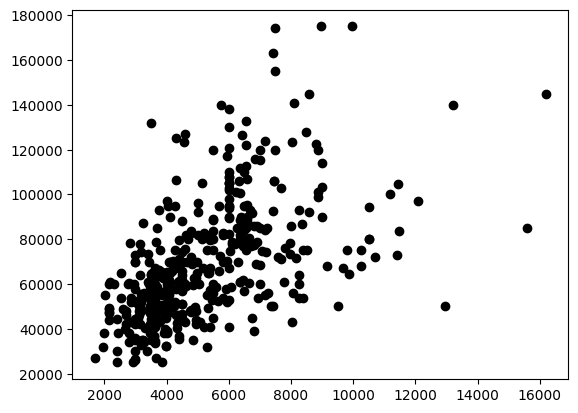

In [27]:
plt.scatter(X_train, Y_train, color='black')